In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df=pd.read_csv('/content/zomato_kpt.csv')

In [ ]:
print(df.columns.tolist())

['Order_ID', 'Merchant_ID', 'Cuisine_Type', 'Cuisine_Complexity', 'Item_Count', 'Item_Details', 'Kitchen_Capacity', 'App_Interaction_Count', 'Subtotal', 'Order_Type', 'Order_Time', 'Is_Peak_Hour', 'OHF', 'WIF', 'Holiday_Flag', 'Location', 'Weather_Traffic_Proxy', 'Rider_Dist_At_Click_Km', 'HPT', 'Past_FOR_Reliability_Score', 'CTR', 'AOC', 'Ambient_Rush_Index', 'RWT', 'Actual_KPT_Mins', 'Merchant_Marked_KPT_Mins', 'Merchant_Trust_Adjusted_KPT', 'Effective_Kitchen_Load', 'Contextual_Cart_Complexity']


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [ ]:
# Measure Error

df["KPT_Error"] = df["Merchant_Marked_KPT_Mins"] - df["Actual_KPT_Mins"]
df["Abs_Error"] = abs(df["KPT_Error"])

df["Abs_Error"].mean() # How much Time

np.float64(16.0669)

In [ ]:
# Error by Peak Hour

df.groupby("Is_Peak_Hour")["Abs_Error"].mean()

,Abs_Error
Is_Peak_Hour,
0,15.973136
1,16.251037


In [ ]:
# Error by Cuisine

df.groupby("Cuisine_Type")["Abs_Error"].mean().sort_values(ascending=False)

,Abs_Error
Cuisine_Type,
Continental,16.429770
North Indian,16.174379
South Indian,16.139542
Street Food,16.110150
Desserts,16.046578
Chinese,15.943318
Italian,15.884475
Biryani,15.831529


In [ ]:
df.groupby("Past_FOR_Reliability_Score")["Abs_Error"].mean()

,Abs_Error
Past_FOR_Reliability_Score,
0.50,16.089715
0.51,16.568571
0.52,16.013699
0.53,16.623611
0.54,16.573469
0.55,16.222535
0.56,16.241935
0.57,14.835938
0.58,16.473770


In [ ]:
df.groupby(pd.qcut(df["AOC"], 4))["Abs_Error"].mean()

/tmp/ipython-input-372/296005059.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["AOC"], 4))["Abs_Error"].mean()


,Abs_Error
AOC,
"(4.999, 19.0]",15.693860
"(19.0, 33.0]",16.158890
"(33.0, 47.0]",16.336335
"(47.0, 60.0]",16.088079


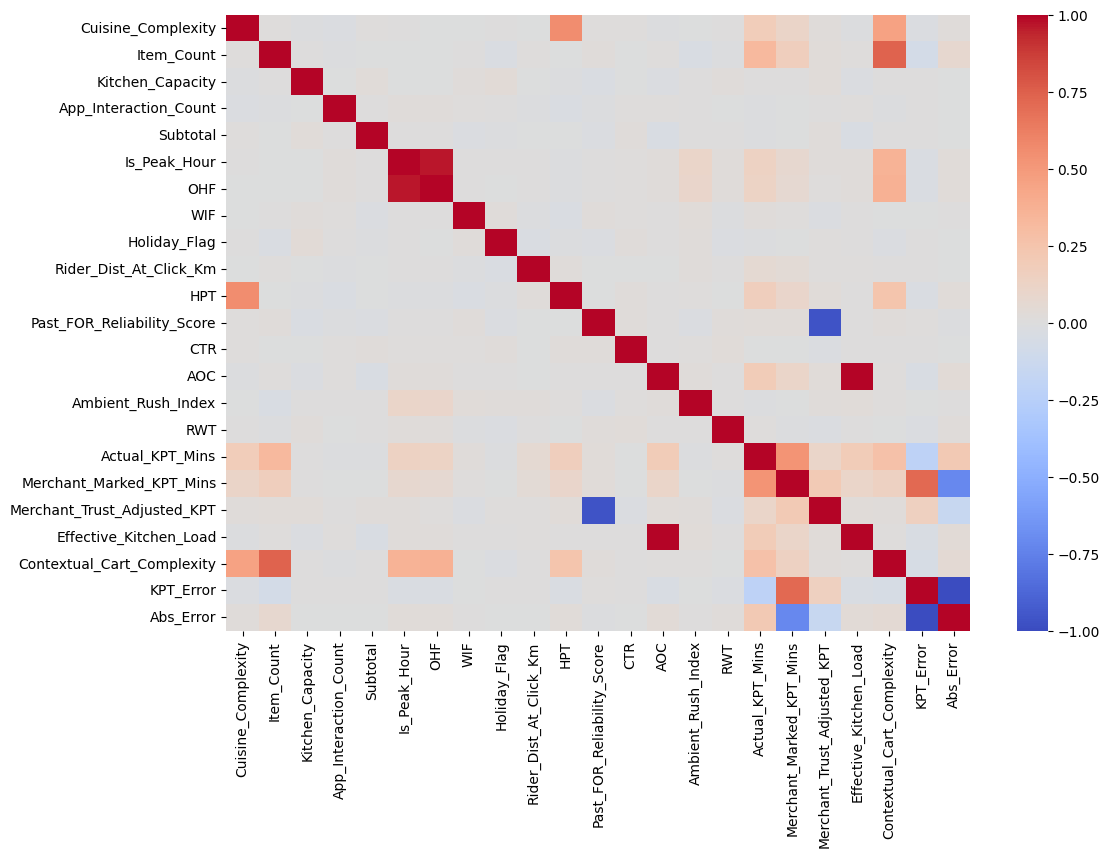

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

## ML Model

In [ ]:
features = [
    "AOC",
    "HPT",
    "RWT",
    "Effective_Kitchen_Load",
    "Cuisine_Complexity",
    "Item_Count",
    "Kitchen_Capacity",
    "Past_FOR_Reliability_Score",
    "Ambient_Rush_Index"
]

X = df[features]

In [ ]:
y = df["Actual_KPT_Mins"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.8793120000000003
RMSE: 2.8756154057870815


In [ ]:
new_data = pd.DataFrame([{
    "AOC": 8,
    "HPT": 18,
    "RWT": 5,
    "Effective_Kitchen_Load": 0.75,
    "Cuisine_Complexity": 3,
    "Item_Count": 4,
    "Kitchen_Capacity": 10,
    "Past_FOR_Reliability_Score": 0.6,
    "Ambient_Rush_Index": 0.8
}])

prediction = model.predict(new_data)
print("Predicted KPT:", prediction[0])

Predicted KPT: 58.093


# Objective of Segmentation

### We want to find:

### Which segment has highest KPT error?

### Where merchant marking fails most?

### Where rider wait is highest?

### Where cancellations spike?

In [ ]:
# Segment by Peak vs Non-Peak

df.groupby("Is_Peak_Hour")["Abs_Error"].mean()

,Abs_Error
Is_Peak_Hour,
0,15.973136
1,16.251037


In [ ]:
# Segment by Active Order Count (AOC)

df["AOC_Bucket"] = pd.qcut(df["AOC"], 4)

df.groupby("AOC_Bucket")["Abs_Error"].mean()

/tmp/ipython-input-372/1077696897.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AOC_Bucket")["Abs_Error"].mean()


,Abs_Error
AOC_Bucket,
"(4.999, 19.0]",15.693860
"(19.0, 33.0]",16.158890
"(33.0, 47.0]",16.336335
"(47.0, 60.0]",16.088079


In [ ]:
# Segment by Merchant Reliability

df.groupby(pd.qcut(df["Past_FOR_Reliability_Score"], 4))["Abs_Error"].mean()

/tmp/ipython-input-372/360057878.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Past_FOR_Reliability_Score"], 4))["Abs_Error"].mean()


,Abs_Error
Past_FOR_Reliability_Score,
"(0.499, 0.53]",16.140644
"(0.53, 0.69]",16.175800
"(0.69, 0.822]",15.892502
"(0.822, 0.98]",16.054960


In [ ]:
# Segment by Cuisine

df.groupby("Cuisine_Type")["Abs_Error"].mean().sort_values(ascending=False)

,Abs_Error
Cuisine_Type,
Continental,16.429770
North Indian,16.174379
South Indian,16.139542
Street Food,16.110150
Desserts,16.046578
Chinese,15.943318
Italian,15.884475
Biryani,15.831529


In [ ]:
# Segment by Rider Waiting Time

df.groupby(pd.qcut(df["RWT"], 4))["Abs_Error"].mean()

/tmp/ipython-input-372/1484631351.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["RWT"], 4))["Abs_Error"].mean()


,Abs_Error
RWT,
"(0.999, 4.1]",16.025215
"(4.1, 7.1]",15.893307
"(7.1, 10.0]",16.257060
"(10.0, 13.0]",16.101852


/tmp/ipython-input-372/830747154.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Abs_Error"], 4))["CTR"].mean()


,CTR
Abs_Error,
"(3.099, 11.8]",0.150336
"(11.8, 15.9]",0.151149
"(15.9, 20.3]",0.149091
"(20.3, 24.7]",0.150515
